# Quickbuild A - Setup Paramaribo

This notebook builds exposure inputs from a Paramaribo AOI using `model_setup`, then prepares example flood maps for multiple water-level scenarios.

In [4]:
from pathlib import Path

import numpy as np
import rasterio

from d_health import model_setup

setup_root = Path("data") / "setup_paramaribo"
flood_extremes_dir = Path("data") / "flood_extremes"

setup_root, flood_extremes_dir

(WindowsPath('data/setup_paramaribo'), WindowsPath('data/flood_extremes'))

In [5]:
# Paramaribo AOI bounds (EPSG:4326): xmin, ymin, xmax, ymax
paramaribo_bbox = (-55.27, 5.78, -55.10, 5.93)

result = model_setup(
    aoi=paramaribo_bbox,
    root_dir=setup_root,
)

print("country_code:", result.country_code)
print("country_name:", result.country_name)
print("settings_toml:", result.settings_toml)
print("population:", result.population)
print("urban_rural:", result.urban_rural)
print("country_indicators:", result.country_indicators)

d_health.model.setup | INFO | Generating exposure inputs for SUR into data\setup_paramaribo
d_health.preprocessing.population | INFO | Fetching WorldPop SUR 2020 (Global_2000_2020_Constrained, constrained) — 36 files, clip=yes
d_health.preprocessing.population | INFO | Downloading child rasters (6 files: 3 age bins × 2 sexes)
d_health.preprocessing.population | INFO | Aggregated child: (181, 205), sum=43573
d_health.preprocessing.population | INFO | Downloading adult rasters (30 files: 15 age bins × 2 sexes)
d_health.preprocessing.population | INFO | Aggregated adult: (181, 205), sum=237297
d_health.io | INFO | Wrote sur_population_2020_combined.nc (1 variable(s))
d_health.preprocessing.population | INFO | Wrote data\setup_paramaribo\data\sur_population_2020_combined.nc (0.2 MB)
d_health.preprocessing.smod | INFO | GHS-SMOD R2023A E2025 (4326, 30ss) — clip=yes
d_health.preprocessing.smod | INFO | Downloading https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_SMOD_GLOBE_R2023A/GH

country_code: SUR
country_name: Suriname
settings_toml: C:\Users\athanasi\Project_files\1_Projects_SITO\Health\D-Health_Tool\d_health\examples\quickbuild\data\setup_paramaribo\settings.toml
population: C:\Users\athanasi\Project_files\1_Projects_SITO\Health\D-Health_Tool\d_health\examples\quickbuild\data\setup_paramaribo\data\sur_population_2020_combined.nc
urban_rural: C:\Users\athanasi\Project_files\1_Projects_SITO\Health\D-Health_Tool\d_health\examples\quickbuild\data\setup_paramaribo\data\sur_urban_rural.nc
country_indicators: C:\Users\athanasi\Project_files\1_Projects_SITO\Health\D-Health_Tool\d_health\examples\quickbuild\data\setup_paramaribo\data\sur_indicators.toml


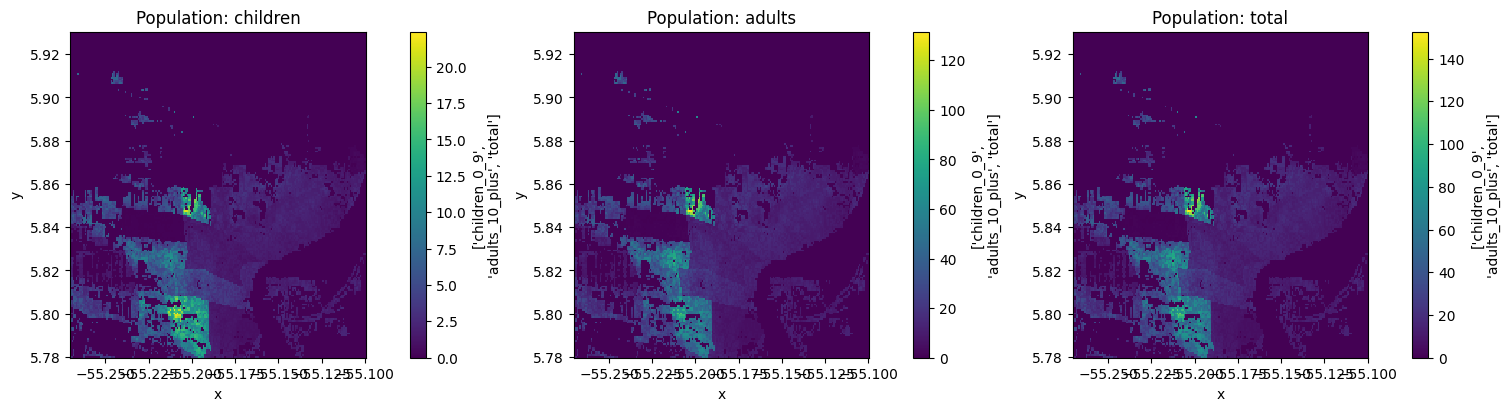

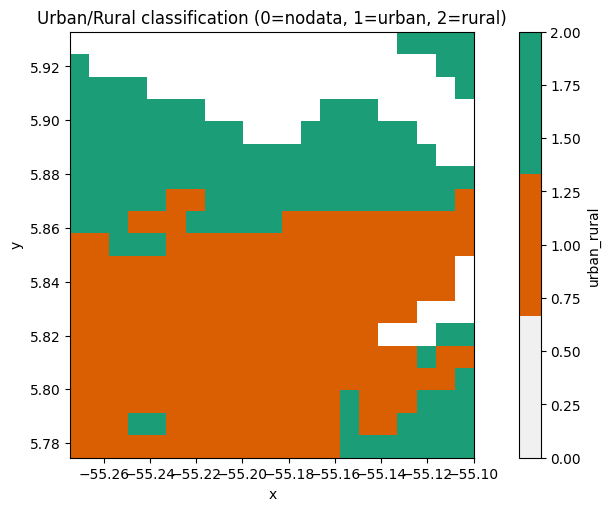

Country: SUR | GDP per capita: 7069.9 USD


,name,urban,rural
0,Safe,20.6935,33.9489
1,Advanced,73.1449,48.4152
2,Basic,5.9795,14.3891
3,None,0.1821,3.2468


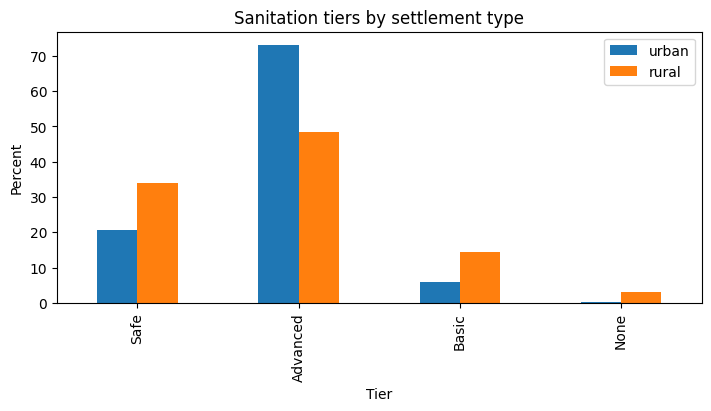

In [6]:
import tomllib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import ListedColormap

# --- Load generated setup artifacts ---
pop_ds = xr.open_dataset(result.population)
pop_var = next(v for v in pop_ds.data_vars if v != "spatial_ref")
population = pop_ds[pop_var]

ur_ds = xr.open_dataset(result.urban_rural)
ur_var = next(v for v in ur_ds.data_vars if v != "spatial_ref")
urban_rural = ur_ds[ur_var]

with result.country_indicators.open("rb") as f:
    indicators = tomllib.load(f)

# --- Plot population groups ---
groups = [str(g) for g in population.coords["group"].values]
n = len(groups)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), constrained_layout=True)
if n == 1:
    axes = [axes]

for ax, g in zip(axes, groups):
    da = population.sel(group=g)
    da.plot(ax=ax, cmap="viridis")
    ax.set_title(f"Population: {g}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.show()

# --- Plot urban/rural map ---
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
cmap = ListedColormap(["#f0f0f0", "#d95f02", "#1b9e77"])
urban_rural.plot(ax=ax, cmap=cmap, vmin=0, vmax=2, add_colorbar=True)
ax.set_title("Urban/Rural classification (0=nodata, 1=urban, 2=rural)")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

# --- Show + plot country indicators ---
san = pd.DataFrame(indicators["sanitation"])
san = san[["name", "urban", "rural"]]
print(f"Country: {indicators['country_code']} | GDP per capita: {indicators['gdp_per_capita']:.1f} USD")
display(san)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
san_plot = san.set_index("name")[["urban", "rural"]]
san_plot.plot(kind="bar", ax=ax)
ax.set_title("Sanitation tiers by settlement type")
ax.set_ylabel("Percent")
ax.set_xlabel("Tier")
plt.show()

In [7]:
# Build scenario flood maps with the same DEM + bathtub approach as the detailed notebook.
import os

import rioxarray  # registers the .rio accessor
from rasterio.transform import from_origin
from rasterio.warp import transform_bounds
from rioxarray.merge import merge_arrays

from d_health.io import from_numpy

aoi_4326 = paramaribo_bbox
flood_crs = "EPSG:32621"
target_res = 30.0
water_levels_m = [1, 2, 3, 5, 10]


def cop_glo30_tile(lat: float, lon: float) -> str:
    ns = "N" if lat >= 0 else "S"
    ew = "E" if lon >= 0 else "W"
    return (
        f"Copernicus_DSM_COG_10_{ns}{abs(int(np.floor(lat))):02d}_00_"
        f"{ew}{abs(int(np.floor(lon))):03d}_00_DEM"
    )


def fetch_dem(bounds_4326, dst_crs, res):
    os.environ.setdefault("GDAL_DISABLE_READDIR_ON_OPEN", "EMPTY_DIR")
    os.environ.setdefault("GDAL_HTTP_TIMEOUT", "30")
    os.environ.setdefault("CPL_VSIL_CURL_USE_HEAD", "NO")

    xmin, ymin, xmax, ymax = bounds_4326
    tiles = sorted({
        cop_glo30_tile(lat, lon)
        for lat in range(int(np.floor(ymin)), int(np.floor(ymax)) + 1)
        for lon in range(int(np.floor(xmin)), int(np.floor(xmax)) + 1)
    })

    arrs = [
        rioxarray.open_rasterio(
            f"/vsicurl/https://copernicus-dem-30m.s3.amazonaws.com/{t}/{t}.tif",
            masked=True,
        )
        for t in tiles
    ]

    dem = arrs[0] if len(arrs) == 1 else merge_arrays(arrs)
    dem = dem.rio.clip_box(xmin, ymin, xmax, ymax)
    dem = dem.rio.reproject(dst_crs, resolution=res)
    if "band" in dem.dims:
        dem = dem.squeeze("band", drop=True)
    return dem.rename("elevation")


def synthetic_dem(bounds_4326, dst_crs, res):
    xmin, ymin, xmax, ymax = transform_bounds("EPSG:4326", dst_crs, *bounds_4326)
    xmin, ymin = np.floor(xmin / res) * res, np.floor(ymin / res) * res
    xmax, ymax = np.ceil(xmax / res) * res, np.ceil(ymax / res) * res
    width = int(round((xmax - xmin) / res))
    height = int(round((ymax - ymin) / res))

    yy, xx = np.mgrid[0:height, 0:width]
    xn, yn = xx / width, yy / height
    elev = 8.0 + 12.0 * xn + 6.0 * yn
    for cx, cy, amp, s in [(0.35, 0.45, -7.0, 0.22), (0.70, 0.65, 9.0, 0.18)]:
        elev += amp * np.exp(-(((xn - cx) / s) ** 2 + ((yn - cy) / s) ** 2))

    transform = from_origin(xmin, ymax, res, res)
    return from_numpy(elev.astype(np.float32), transform, dst_crs, name="elevation")


def bathtub(elev_da, water_level, noise=0.05):
    elev = elev_da.values.astype(np.float32)
    depth = np.clip(water_level - elev, 0.0, None).astype(np.float32)
    depth[depth < noise] = 0.0
    depth[np.isnan(elev)] = 0.0
    da = elev_da.copy(data=depth).rename("flood_depth")
    da = da.assign_attrs(long_name="flood_depth_m", units="m")
    da = da.rio.write_nodata(0)
    return da


try:
    elevation = fetch_dem(aoi_4326, flood_crs, target_res)
    print(f"DEM: Copernicus GLO-30 {tuple(elevation.shape)} in {elevation.rio.crs}")
except Exception as exc:
    print(f"DEM fetch failed ({type(exc).__name__}: {exc}); using synthetic terrain.")
    elevation = synthetic_dem(aoi_4326, flood_crs, target_res)
    print(f"DEM: synthetic {tuple(elevation.shape)} in {elevation.rio.crs}")

flood_extremes_dir.mkdir(parents=True, exist_ok=True)
for wl in water_levels_m:
    flood = bathtub(elevation, float(wl))
    out_path = flood_extremes_dir / f"flood_wl{wl:02d}m_paramaribo.tif"
    flood.rio.to_raster(out_path, dtype="float32", compress="deflate")

sorted(p.name for p in flood_extremes_dir.glob("flood_wl*m_paramaribo.tif"))

DEM: Copernicus GLO-30 (557, 631) in EPSG:32621


['flood_wl01m_paramaribo.tif',
 'flood_wl02m_paramaribo.tif',
 'flood_wl03m_paramaribo.tif',
 'flood_wl05m_paramaribo.tif',
 'flood_wl10m_paramaribo.tif']